<a href="https://colab.research.google.com/github/Nkeh/ml-algorithms/blob/main/pca_across_all_problems_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA — Applied Across All Four ML Problems

**Course ML Project | Supplementary Notebook**

---

This notebook applies **Principal Component Analysis (PCA)** to all four course datasets and shows how it improves (or doesn't improve) each model. It is meant to be read alongside the four main project notebooks.

| Problem | Model | Dataset | PCA benefit |
|---|---|---|---|
| 1 | Linear Regression | California Housing | Resolves multicollinearity |
| 2 | Logistic Regression | Pima Diabetes | Reduces correlated features |
| 3 | Decision Tree | Loan Approval (synthetic) | Noise reduction |
| 4 | KNN | Iris | Fights curse of dimensionality + 2D visualisation |

### What PCA does — recap

Given a feature matrix $X \in \mathbb{R}^{n \times p}$ (n samples, p features), PCA finds a new set of **orthogonal axes** — the principal components — that maximise variance:

$$\Sigma = \frac{1}{n-1} X^T X \quad \xrightarrow{\text{eigen-decomposition}} \quad \Sigma \mathbf{v}_i = \lambda_i \mathbf{v}_i$$

We keep the top $k$ eigenvectors (those with the largest $\lambda_i$) and project:

$$X_{\text{reduced}} = X \cdot V_k \quad \text{where } V_k \in \mathbb{R}^{p \times k}$$

The **explained variance ratio** of component $i$ is $\lambda_i \,/\, \sum_j \lambda_j$. We choose $k$ using a **scree plot** — the elbow point where adding more components gives diminishing returns.

### The three-step rule before applying PCA

1. **Standardise first** — PCA is sensitive to scale. Always `StandardScaler` before `PCA`.
2. **Choose k** — retain enough components to explain ≥ 95% of cumulative variance.
3. **Compare with and without** — PCA is not always beneficial. We always compare model performance before and after.

In [1]:
# ── Shared imports for all four problems ───────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing  import StandardScaler
from sklearn.pipeline       import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (r2_score, mean_squared_error,
                              accuracy_score, classification_report)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

BLUE  = '#378ADD'
CORAL = '#D85A30'
TEAL  = '#1D9E75'
AMBER = '#BA7517'
PURP  = '#7F77DD'
GRAY  = '#888780'

def scree_plot(pca, ax, title, color=BLUE):
    """Reusable scree plot: individual + cumulative explained variance."""
    evr  = pca.explained_variance_ratio_
    cumv = np.cumsum(evr)
    x    = np.arange(1, len(evr) + 1)
    ax2  = ax.twinx()
    ax.bar(x, evr * 100, color=color, alpha=0.65, width=0.5, label='Individual')
    ax2.plot(x, cumv * 100, color=CORAL, linewidth=2,
             marker='o', markersize=5, label='Cumulative')
    ax2.axhline(95, color=GRAY, linewidth=1, linestyle='--', alpha=0.6)
    ax2.text(len(evr) * 0.98, 96, '95% threshold', ha='right',
             fontsize=9, color=GRAY)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Principal component')
    ax.set_ylabel('Individual variance (%)', color=color)
    ax2.set_ylabel('Cumulative variance (%)', color=CORAL)
    ax2.set_ylim(0, 105)
    lines1, lab1 = ax.get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lab1 + lab2, fontsize=9, loc='center right')
    return evr, cumv

print('Shared setup complete.')

Shared setup complete.


---
## Problem 1 — Linear Regression + PCA
### Dataset: California Housing

**Why PCA helps here:**  
After feature engineering, several columns are strongly correlated:
- `total_rooms`, `total_bedrooms`, `households`, `population` all measure block size.
- `rooms_per_household` and `total_rooms` partially overlap.

This **multicollinearity** inflates the variance of coefficient estimates. In matrix terms, $(X^T X)$ becomes nearly singular — its inverse amplifies small errors. PCA replaces correlated features with orthogonal components, making $(X^T X)$ well-conditioned.

**What to look for:**  
- Whether R² improves or stays the same after PCA  
- How many components are needed to retain 95% variance  
- Whether the coefficient instability (large std errors) is reduced

In [2]:
# ── Load & prepare California Housing ─────────────────────────────────────────
URL = 'https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv'
df1 = pd.read_csv(URL)
df1 = df1[df1['median_house_value'] < 500001].copy()
df1['total_bedrooms'] = df1['total_bedrooms'].fillna(df1['total_bedrooms'].median())
df1['LogHouseValue']  = np.log(df1['median_house_value'])

# Feature engineering
df1['rooms_per_household']      = df1['total_rooms']    / df1['households']
df1['bedrooms_per_room']        = df1['total_bedrooms'] / df1['total_rooms']
df1['population_per_household'] = df1['population']     / df1['households']
df1['income_sq']                = df1['median_income']  ** 2
df1 = pd.get_dummies(df1, columns=['ocean_proximity'], drop_first=True)

FEAT1 = ['median_income', 'housing_median_age', 'total_rooms', 'total_bedrooms',
         'population', 'households', 'rooms_per_household', 'bedrooms_per_room',
         'population_per_household', 'income_sq'] + \
        [c for c in df1.columns if c.startswith('ocean_proximity_')]

X1 = df1[FEAT1]
y1 = df1['LogHouseValue']
X1_tr, X1_te, y1_tr, y1_te = train_test_split(X1, y1, test_size=0.2, random_state=42)

print(f'Features: {len(FEAT1)}')
print(f'Train: {len(X1_tr)} | Test: {len(X1_te)}')

Features: 14
Train: 15740 | Test: 3935


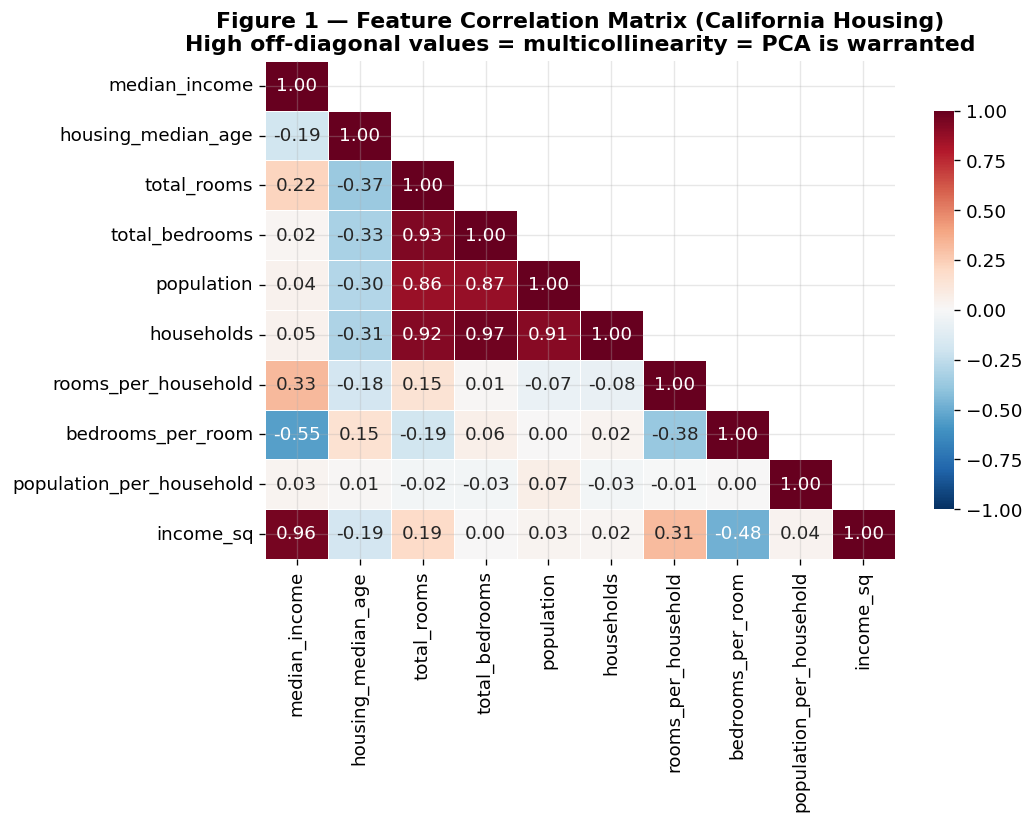

In [3]:
# ── Correlation heatmap — shows why PCA is needed ─────────────────────────────
num_only = ['median_income', 'housing_median_age', 'total_rooms', 'total_bedrooms',
            'population', 'households', 'rooms_per_household',
            'bedrooms_per_room', 'population_per_household', 'income_sq']

corr = df1[num_only].corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Figure 1 — Feature Correlation Matrix (California Housing)\n'
             'High off-diagonal values = multicollinearity = PCA is warranted',
             fontweight='bold')
plt.tight_layout()
plt.show()

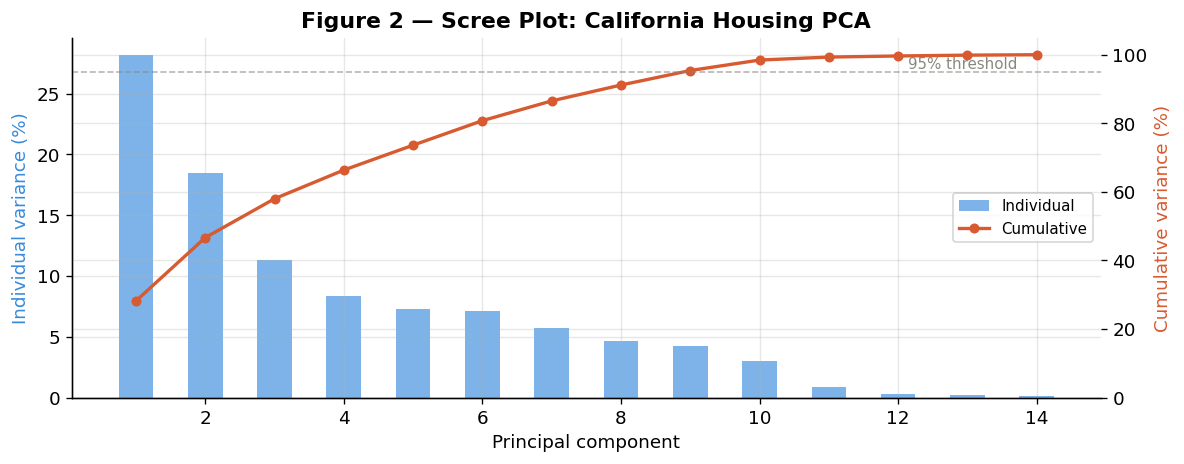

Components needed for 95% variance: 9 (out of 14)
  PC1: 28.2%  cumulative: 28.2%
  PC2: 18.5%  cumulative: 46.7%
  PC3: 11.3%  cumulative: 58.0%
  PC4: 8.4%  cumulative: 66.4%
  PC5: 7.3%  cumulative: 73.6%
  PC6: 7.1%  cumulative: 80.8%
  PC7: 5.8%  cumulative: 86.5%
  PC8: 4.6%  cumulative: 91.2%
  PC9: 4.2%  cumulative: 95.4%


In [4]:
from sklearn.linear_model import LinearRegression, Ridge

# ── Fit PCA on training data (standardise first) ──────────────────────────────
scaler1 = StandardScaler()
X1_tr_sc = scaler1.fit_transform(X1_tr)
X1_te_sc = scaler1.transform(X1_te)

pca1_full = PCA()
pca1_full.fit(X1_tr_sc)

fig, ax = plt.subplots(figsize=(10, 4))
evr1, cumv1 = scree_plot(pca1_full, ax,
    'Figure 2 — Scree Plot: California Housing PCA', color=BLUE)
plt.tight_layout()
plt.show()

# How many components for 95%?
k1 = np.argmax(cumv1 >= 0.95) + 1
print(f'Components needed for 95% variance: {k1} (out of {len(evr1)})')
for i, (e, c) in enumerate(zip(evr1[:k1], cumv1[:k1]), 1):
    print(f'  PC{i}: {e*100:.1f}%  cumulative: {c*100:.1f}%')

In [5]:
# ── Compare: OLS baseline vs OLS + PCA ────────────────────────────────────────
def reg_score(pipe, Xtr, ytr, Xte, yte, label):
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    r2   = r2_score(yte, pred)
    rmse = np.sqrt(mean_squared_error(np.exp(yte), np.exp(pred)))
    cv   = cross_val_score(pipe, Xtr, ytr, cv=5, scoring='r2').mean()
    print(f'{label:<35} R²={r2:.4f}  CV-R²={cv:.4f}  RMSE=${rmse:,.0f}')
    return r2

print('Model comparison — California Housing')
print('-' * 70)
pipe_ols_base  = Pipeline([('sc', StandardScaler()), ('m', LinearRegression())])
pipe_ols_pca   = Pipeline([('sc', StandardScaler()), ('pca', PCA(n_components=k1)), ('m', LinearRegression())])
pipe_ridge_pca = Pipeline([('sc', StandardScaler()), ('pca', PCA(n_components=k1)), ('m', Ridge(alpha=1.0))])

reg_score(pipe_ols_base,  X1_tr, y1_tr, X1_te, y1_te, 'OLS (no PCA)')
reg_score(pipe_ols_pca,   X1_tr, y1_tr, X1_te, y1_te, f'OLS + PCA ({k1} components)')
reg_score(pipe_ridge_pca, X1_tr, y1_tr, X1_te, y1_te, f'Ridge + PCA ({k1} components)')

Model comparison — California Housing
----------------------------------------------------------------------
OLS (no PCA)                        R²=0.6527  CV-R²=0.6461  RMSE=$62,991
OLS + PCA (9 components)            R²=0.5986  CV-R²=0.5891  RMSE=$107,306
Ridge + PCA (9 components)          R²=0.5986  CV-R²=0.5891  RMSE=$107,297


0.5986401324014917

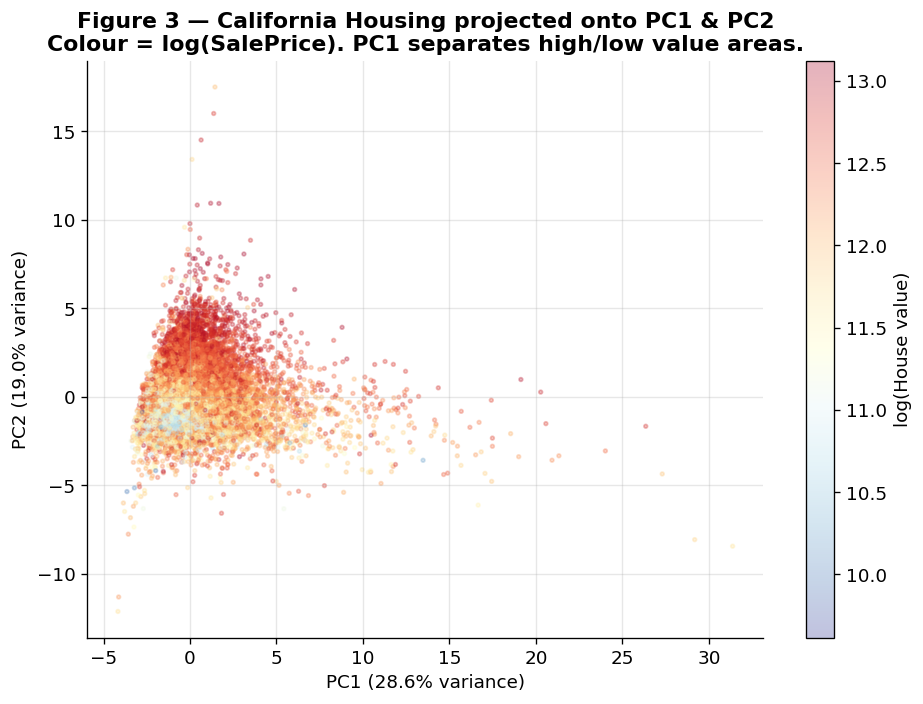


Top feature loadings on PC1:
total_rooms                   0.487
households                    0.476
total_bedrooms                0.473
population                    0.464
median_income                 0.130
income_sq                     0.117
rooms_per_household           0.052
ocean_proximity_INLAND        0.004
population_per_household     -0.000
ocean_proximity_ISLAND       -0.008
ocean_proximity_NEAR OCEAN   -0.008
ocean_proximity_NEAR BAY     -0.034
bedrooms_per_room            -0.079
housing_median_age           -0.238
Name: PC1, dtype: float64


In [6]:
# ── PC1 vs PC2 scatter (coloured by house value) ──────────────────────────────
pca1_2d = PCA(n_components=2)
X1_2d   = pca1_2d.fit_transform(scaler1.transform(X1))

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X1_2d[:, 0], X1_2d[:, 1],
                c=y1, cmap='RdYlBu_r', alpha=0.3, s=5)
plt.colorbar(sc, ax=ax, label='log(House value)')
ax.set_title('Figure 3 — California Housing projected onto PC1 & PC2\n'
             'Colour = log(SalePrice). PC1 separates high/low value areas.',
             fontweight='bold')
ax.set_xlabel(f'PC1 ({pca1_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca1_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

# Loadings: which original features drive PC1?
loadings1 = pd.DataFrame(
    pca1_2d.components_.T,
    index=FEAT1,
    columns=['PC1', 'PC2']
).sort_values('PC1', ascending=False)
print('\nTop feature loadings on PC1:')
print(loadings1['PC1'].round(3))

---
## Problem 2 — Logistic Regression + PCA
### Dataset: Pima Indians Diabetes

**Why PCA helps here:**  
The Pima dataset has 8 medical features, several of which are moderately correlated (e.g. `Glucose` and `Insulin`, `BMI` and `SkinThickness`). For logistic regression, correlated features can cause the decision boundary to be unstable — small perturbations in the data shift the coefficients a lot.

PCA decorrelates the input space so the logistic regression fits a cleaner, more stable boundary.

**The decision boundary** in the original $p$-dimensional space is:

$$\mathbf{w}^T \mathbf{x} + b = 0$$

After PCA it becomes:

$$\mathbf{w}^T V_k^T \mathbf{x} + b = 0$$

The boundary is now in a lower-dimensional orthogonal space — simpler and less noisy.

In [7]:
# ── Load Pima Diabetes from OpenML URL ────────────────────────────────────────
PIMA_URL = ('https://raw.githubusercontent.com/plotly/datasets/master/'
            'diabetes.csv')
try:
    df2 = pd.read_csv(PIMA_URL)
except Exception:
    # Fallback: build from sklearn's built-in load_diabetes (regression)
    # We'll use a reliable mirror instead
    PIMA_URL2 = ('https://raw.githubusercontent.com/jbrownlee/Datasets/'
                 'master/pima-indians-diabetes.data.csv')
    cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
    df2 = pd.read_csv(PIMA_URL2, header=None, names=cols)

# Ensure correct column names
if 'Outcome' not in df2.columns and 'Diabetes' in df2.columns:
    df2 = df2.rename(columns={'Diabetes': 'Outcome'})

FEAT2  = [c for c in df2.columns if c != 'Outcome']
TARGET2 = 'Outcome'

# Zero values in medical columns are physiologically impossible — treat as missing
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    if col in df2.columns:
        df2[col] = df2[col].replace(0, np.nan)
        df2[col] = df2[col].fillna(df2[col].median())

X2 = df2[FEAT2]
y2 = df2[TARGET2]
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2,
                                                random_state=42, stratify=y2)
print(f'Pima dataset: {df2.shape[0]} rows, {len(FEAT2)} features')
print(f'Class balance: {y2.value_counts().to_dict()}')

Pima dataset: 768 rows, 8 features
Class balance: {0: 500, 1: 268}


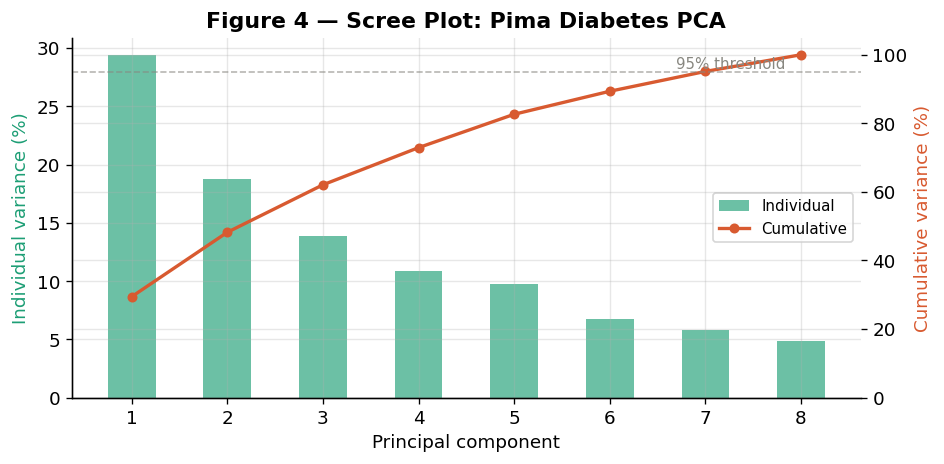

Components for 95% variance: 7 (out of 8)


In [8]:
# ── Scree plot for Pima ───────────────────────────────────────────────────────
scaler2 = StandardScaler()
X2_tr_sc = scaler2.fit_transform(X2_tr)

pca2_full = PCA().fit(X2_tr_sc)

fig, ax = plt.subplots(figsize=(8, 4))
evr2, cumv2 = scree_plot(pca2_full, ax,
    'Figure 4 — Scree Plot: Pima Diabetes PCA', color=TEAL)
plt.tight_layout()
plt.show()

k2 = np.argmax(cumv2 >= 0.95) + 1
print(f'Components for 95% variance: {k2} (out of {len(evr2)})')

In [9]:
from sklearn.linear_model import LogisticRegression

def clf_score(pipe, Xtr, ytr, Xte, yte, label):
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    acc  = accuracy_score(yte, pred)
    cv   = cross_val_score(pipe, Xtr, ytr, cv=5, scoring='accuracy').mean()
    print(f'{label:<40} Acc={acc:.4f}  CV-Acc={cv:.4f}')
    return acc

print('Model comparison — Pima Diabetes')
print('-' * 70)
pipe_lr_base = Pipeline([('sc', StandardScaler()),
                          ('m',  LogisticRegression(max_iter=1000, random_state=42))])
pipe_lr_pca  = Pipeline([('sc',  StandardScaler()),
                          ('pca', PCA(n_components=k2)),
                          ('m',   LogisticRegression(max_iter=1000, random_state=42))])

clf_score(pipe_lr_base, X2_tr, y2_tr, X2_te, y2_te, 'Logistic Regression (no PCA)')
clf_score(pipe_lr_pca,  X2_tr, y2_tr, X2_te, y2_te, f'Logistic Regression + PCA ({k2} comps)')

Model comparison — Pima Diabetes
----------------------------------------------------------------------
Logistic Regression (no PCA)             Acc=0.7078  CV-Acc=0.7818
Logistic Regression + PCA (7 comps)      Acc=0.6948  CV-Acc=0.7818


0.6948051948051948

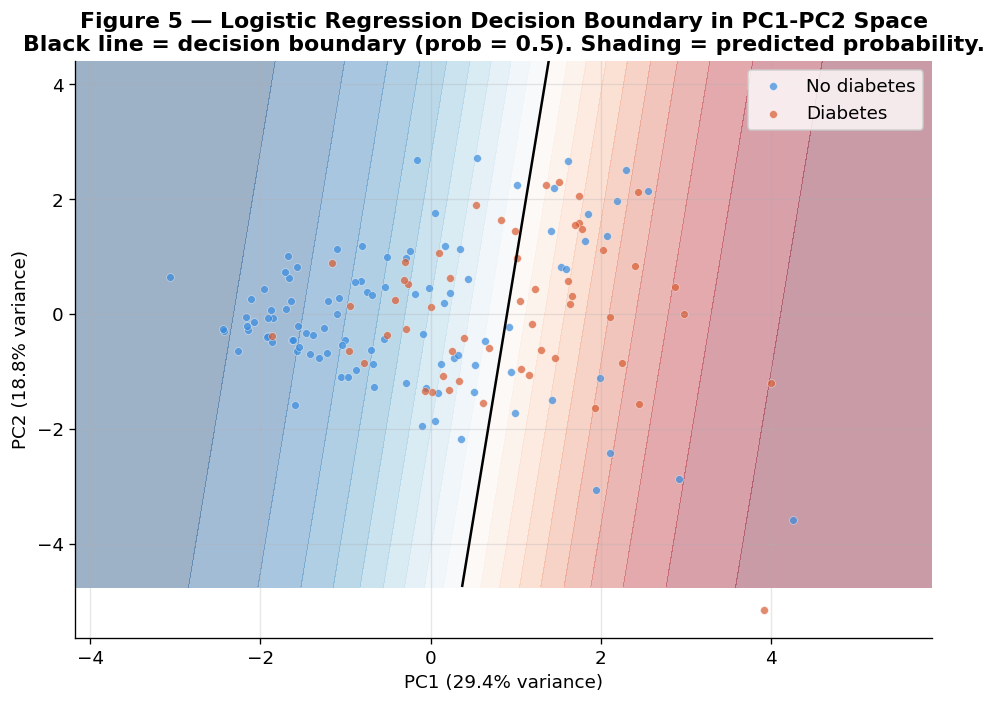

Acc on 2D PCA projection (for visualisation only): 0.7013


In [10]:
# ── Decision boundary visualisation in PC1-PC2 space ─────────────────────────
pca2_2d = PCA(n_components=2)
X2_tr_2d = pca2_2d.fit_transform(scaler2.transform(X2_tr))
X2_te_2d = pca2_2d.transform(scaler2.transform(X2_te))

lr_2d = LogisticRegression(max_iter=1000, random_state=42)
lr_2d.fit(X2_tr_2d, y2_tr)

xx, yy = np.meshgrid(
    np.linspace(X2_tr_2d[:, 0].min()-0.5, X2_tr_2d[:, 0].max()+0.5, 300),
    np.linspace(X2_tr_2d[:, 1].min()-0.5, X2_tr_2d[:, 1].max()+0.5, 300)
)
Z = lr_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.4)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.5)

for cls, color, label in [(0, BLUE, 'No diabetes'), (1, CORAL, 'Diabetes')]:
    mask = y2_te.values == cls
    ax.scatter(X2_te_2d[mask, 0], X2_te_2d[mask, 1],
               c=color, s=22, alpha=0.7, label=label, edgecolors='white', linewidths=0.3)

ax.set_title('Figure 5 — Logistic Regression Decision Boundary in PC1-PC2 Space\n'
             'Black line = decision boundary (prob = 0.5). Shading = predicted probability.',
             fontweight='bold')
ax.set_xlabel(f'PC1 ({pca2_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca2_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Acc on 2D PCA projection (for visualisation only): '
      f'{accuracy_score(y2_te, lr_2d.predict(X2_te_2d)):.4f}')

---
## Problem 3 — Decision Tree + PCA
### Dataset: Loan Approval (synthetic)

**Why PCA is less critical here — but still instructive:**  
Decision trees split on one feature at a time using Gini impurity:

$$\text{Gini}(S) = 1 - \sum_{k=1}^{K} p_k^2$$

Because each split only looks at one feature, correlated features don't destabilise the model the way they do in linear models. The tree simply picks the most informative feature at each node and ignores the rest.

**However**, PCA can still help by:
- **Denoising** — removing components that carry very little variance (likely noise)
- **Reducing overfitting** — fewer input dimensions → shallower trees needed
- **Speeding up** grid search when many features are present

We expect PCA to make little to no improvement on accuracy, but we verify this empirically.

In [11]:
# ── Generate synthetic loan approval dataset ───────────────────────────────────
# (Reproducible, no internet required)
rng = np.random.default_rng(42)
n   = 1000

income        = rng.normal(55000, 20000, n).clip(15000, 150000)
credit_score  = rng.normal(680, 80, n).clip(300, 850)
loan_amount   = rng.normal(180000, 70000, n).clip(20000, 500000)
emp_years     = rng.exponential(5, n).clip(0, 40)
debt_ratio    = rng.beta(2, 5, n)                      # 0-1, lower is better
num_accounts  = rng.poisson(4, n).clip(1, 15)
missed_pymts  = rng.poisson(0.5, n).clip(0, 10)
prop_value    = loan_amount * rng.uniform(1.1, 2.0, n) # correlated with loan
age           = rng.normal(38, 10, n).clip(21, 75)

# Target: loan approved (logistic rule with noise)
score = (credit_score / 850 * 3
         + income / 150000 * 2
         - debt_ratio * 2
         - missed_pymts * 0.5
         + emp_years / 40
         + rng.normal(0, 0.3, n))
approved = (score > score.mean()).astype(int)

df3 = pd.DataFrame({
    'income': income, 'credit_score': credit_score,
    'loan_amount': loan_amount, 'emp_years': emp_years,
    'debt_ratio': debt_ratio, 'num_accounts': num_accounts,
    'missed_payments': missed_pymts, 'property_value': prop_value,
    'age': age, 'approved': approved
})

FEAT3 = [c for c in df3.columns if c != 'approved']
X3 = df3[FEAT3]
y3 = df3['approved']
X3_tr, X3_te, y3_tr, y3_te = train_test_split(X3, y3, test_size=0.2,
                                                random_state=42, stratify=y3)
print(f'Loan dataset: {df3.shape[0]} rows, {len(FEAT3)} features')
print(f'Approval rate: {y3.mean():.1%}')

Loan dataset: 1000 rows, 9 features
Approval rate: 51.5%


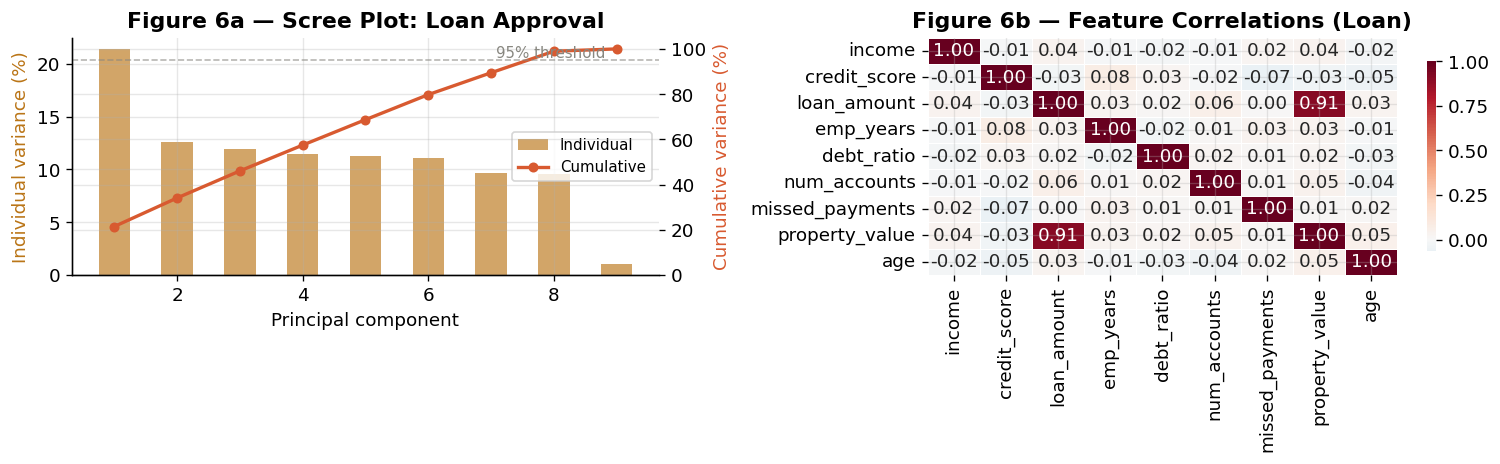

Components for 95% variance: 8

Model comparison — Loan Approval (Decision Tree)
----------------------------------------------------------------------
Decision Tree (no PCA)                   Acc=0.8100  CV-Acc=0.7775
Decision Tree + PCA (8 comps)            Acc=0.7550  CV-Acc=0.7500


0.755

In [12]:
from sklearn.tree import DecisionTreeClassifier

scaler3  = StandardScaler()
pca3_full = PCA().fit(scaler3.fit_transform(X3_tr))
evr3, cumv3 = pca3_full.explained_variance_ratio_, np.cumsum(pca3_full.explained_variance_ratio_)
k3 = np.argmax(cumv3 >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
scree_plot(pca3_full, axes[0],
    'Figure 6a — Scree Plot: Loan Approval', color=AMBER)

# Feature correlation
sns.heatmap(X3.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Figure 6b — Feature Correlations (Loan)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Components for 95% variance: {k3}')

print('\nModel comparison — Loan Approval (Decision Tree)')
print('-' * 70)
pipe_dt_base = Pipeline([('sc', StandardScaler()),
                          ('m',  DecisionTreeClassifier(max_depth=6, random_state=42))])
pipe_dt_pca  = Pipeline([('sc',  StandardScaler()),
                          ('pca', PCA(n_components=k3)),
                          ('m',   DecisionTreeClassifier(max_depth=6, random_state=42))])

clf_score(pipe_dt_base, X3_tr, y3_tr, X3_te, y3_te, 'Decision Tree (no PCA)')
clf_score(pipe_dt_pca,  X3_tr, y3_tr, X3_te, y3_te, f'Decision Tree + PCA ({k3} comps)')

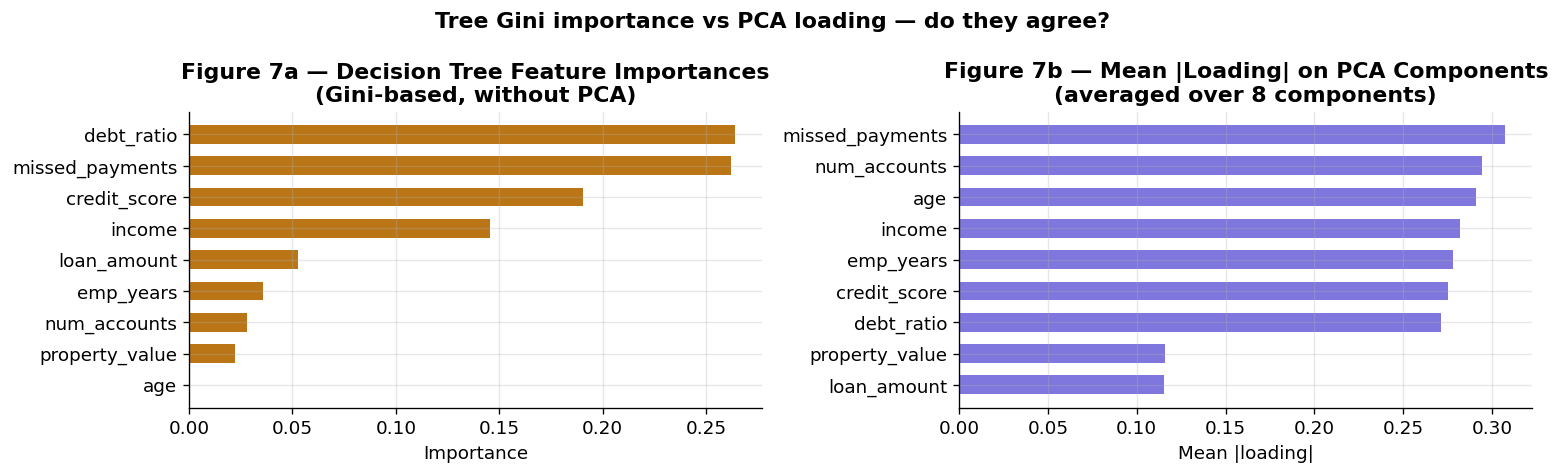

Tree top 3: ['debt_ratio', 'missed_payments', 'credit_score']
PCA  top 3: ['missed_payments', 'num_accounts', 'age']


In [13]:
# ── Feature importance vs PCA loadings comparison ────────────────────────────
pipe_dt_base.fit(X3_tr, y3_tr)
importances = pd.Series(pipe_dt_base.named_steps['m'].feature_importances_,
                         index=FEAT3).sort_values(ascending=False)

pca3_k = PCA(n_components=k3).fit(scaler3.transform(X3_tr))
loadings3 = pd.DataFrame(
    np.abs(pca3_k.components_).mean(axis=0),
    index=FEAT3, columns=['mean_abs_loading']
).sort_values('mean_abs_loading', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].barh(importances.index, importances.values, color=AMBER,
             edgecolor='none', height=0.6)
axes[0].invert_yaxis()
axes[0].set_title('Figure 7a — Decision Tree Feature Importances\n'
                  '(Gini-based, without PCA)', fontweight='bold')
axes[0].set_xlabel('Importance')

axes[1].barh(loadings3.index, loadings3['mean_abs_loading'],
             color=PURP, edgecolor='none', height=0.6)
axes[1].invert_yaxis()
axes[1].set_title('Figure 7b — Mean |Loading| on PCA Components\n'
                  f'(averaged over {k3} components)', fontweight='bold')
axes[1].set_xlabel('Mean |loading|')

plt.suptitle('Tree Gini importance vs PCA loading — do they agree?', fontweight='bold')
plt.tight_layout()
plt.show()

print('Tree top 3:', importances.head(3).index.tolist())
print('PCA  top 3:', loadings3.head(3).index.tolist())

---
## Problem 4 — KNN + PCA
### Dataset: Iris

**Why PCA is most impactful here:**

KNN classifies a point by computing its **Euclidean distance** to all training points:

$$d(\mathbf{x}, \mathbf{x}') = \sqrt{\sum_{j=1}^{p}(x_j - x_j')^2}$$

Two problems arise in higher dimensions:

1. **Curse of dimensionality** — in high-dimensional space, all points become approximately equidistant from each other. Distances lose discriminative power. The ratio of the maximum to minimum distance between any two points converges to 1 as $p \to \infty$.

2. **Redundant dimensions add noise** — if two features are perfectly correlated, they double-count that direction in the distance formula, biasing the nearest-neighbour search.

PCA solves both: it reduces $p$, removes redundant dimensions, and orders the remaining ones by how much variance (signal) they carry.

**For Iris specifically:** The 4 original features collapse to 2 principal components that capture ~96% of variance. This lets us **visualise the decision boundaries directly** in 2D — which is impossible in the original 4D space.

In [14]:
from sklearn.datasets  import load_iris
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap

iris     = load_iris()
X4_full  = pd.DataFrame(iris.data,   columns=iris.feature_names)
y4       = pd.Series(iris.target)
names4   = iris.target_names          # ['setosa', 'versicolor', 'virginica']

X4_tr, X4_te, y4_tr, y4_te = train_test_split(
    X4_full, y4, test_size=0.2, random_state=42, stratify=y4)

print(f'Iris: {X4_full.shape[0]} rows, {X4_full.shape[1]} features, 3 classes')

Iris: 150 rows, 4 features, 3 classes


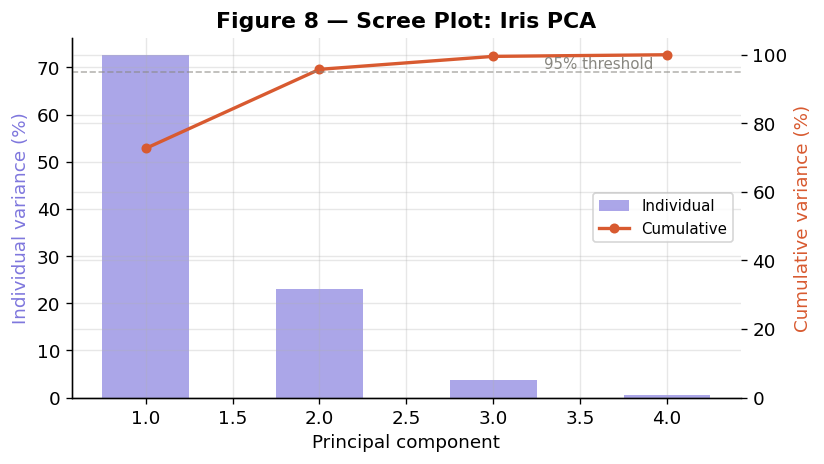

Components for 95% variance: 2
  PC1: 72.7%  cumulative: 72.7%
  PC2: 23.1%  cumulative: 95.7%
  PC3: 3.8%  cumulative: 99.5%
  PC4: 0.5%  cumulative: 100.0%


In [15]:
# ── Scree plot for Iris ───────────────────────────────────────────────────────
scaler4   = StandardScaler()
X4_tr_sc  = scaler4.fit_transform(X4_tr)
pca4_full = PCA().fit(X4_tr_sc)
evr4, cumv4 = pca4_full.explained_variance_ratio_, np.cumsum(pca4_full.explained_variance_ratio_)
k4 = np.argmax(cumv4 >= 0.95) + 1

fig, ax = plt.subplots(figsize=(7, 4))
scree_plot(pca4_full, ax, 'Figure 8 — Scree Plot: Iris PCA', color=PURP)
plt.tight_layout()
plt.show()

print(f'Components for 95% variance: {k4}')
for i, (e, c) in enumerate(zip(evr4, cumv4), 1):
    print(f'  PC{i}: {e*100:.1f}%  cumulative: {c*100:.1f}%')

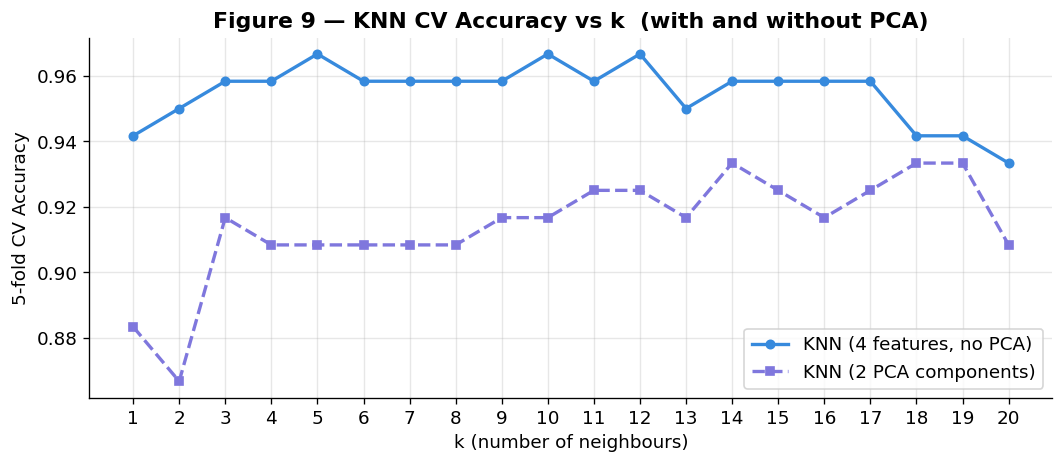

Best k (no PCA): 5  CV-acc=0.9667
Best k (PCA):    14  CV-acc=0.9333


In [16]:
# ── KNN: accuracy vs k, with and without PCA ──────────────────────────────────
k_vals = range(1, 21)
acc_no_pca, acc_pca = [], []

for k in k_vals:
    p_base = Pipeline([('sc', StandardScaler()),
                        ('m',  KNeighborsClassifier(n_neighbors=k))])
    p_pca  = Pipeline([('sc',  StandardScaler()),
                        ('pca', PCA(n_components=2)),
                        ('m',   KNeighborsClassifier(n_neighbors=k))])
    acc_no_pca.append(cross_val_score(p_base, X4_tr, y4_tr, cv=5).mean())
    acc_pca.append(cross_val_score(p_pca,  X4_tr, y4_tr, cv=5).mean())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_vals, acc_no_pca, color=BLUE,  linewidth=2,
        marker='o', markersize=5, label='KNN (4 features, no PCA)')
ax.plot(k_vals, acc_pca,    color=PURP,  linewidth=2,
        marker='s', markersize=5, linestyle='--', label='KNN (2 PCA components)')
ax.set_title('Figure 9 — KNN CV Accuracy vs k  (with and without PCA)', fontweight='bold')
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel('5-fold CV Accuracy')
ax.set_xticks(list(k_vals))
ax.legend()
plt.tight_layout()
plt.show()

best_k_base = k_vals[np.argmax(acc_no_pca)]
best_k_pca  = k_vals[np.argmax(acc_pca)]
print(f'Best k (no PCA): {best_k_base}  CV-acc={max(acc_no_pca):.4f}')
print(f'Best k (PCA):    {best_k_pca}  CV-acc={max(acc_pca):.4f}')

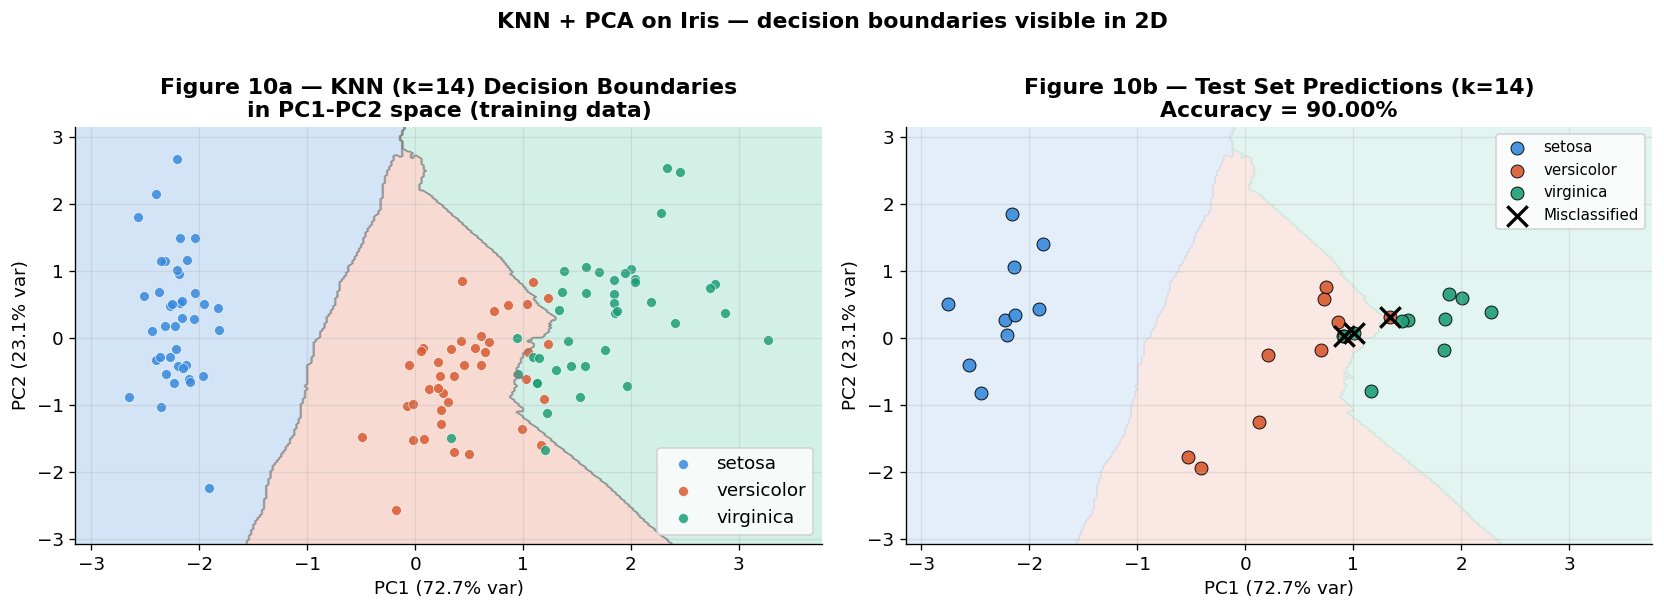


Classification report (KNN + PCA on test set):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [17]:
# ── KNN decision boundary in 2D PCA space (the key visualisation) ─────────────
pca4_2d  = PCA(n_components=2)
X4_tr_2d = pca4_2d.fit_transform(scaler4.transform(X4_tr))
X4_te_2d = pca4_2d.transform(scaler4.transform(X4_te))

knn_2d = KNeighborsClassifier(n_neighbors=best_k_pca)
knn_2d.fit(X4_tr_2d, y4_tr)

h = 0.02
x_min, x_max = X4_tr_2d[:, 0].min() - 0.5, X4_tr_2d[:, 0].max() + 0.5
y_min, y_max = X4_tr_2d[:, 1].min() - 0.5, X4_tr_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

colors_bg   = ListedColormap(['#C8DEF5', '#F5D2C8', '#C8EDE2'])
colors_pts  = [BLUE, CORAL, TEAL]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: decision boundary
axes[0].contourf(xx, yy, Z, cmap=colors_bg, alpha=0.8)
axes[0].contour(xx, yy, Z,  colors='gray',  linewidths=0.6, alpha=0.5)
for cls, col, nm in zip([0, 1, 2], colors_pts, names4):
    mask = y4_tr.values == cls
    axes[0].scatter(X4_tr_2d[mask, 0], X4_tr_2d[mask, 1],
                    c=col, s=35, alpha=0.85, label=nm,
                    edgecolors='white', linewidths=0.4)
axes[0].set_title(f'Figure 10a — KNN (k={best_k_pca}) Decision Boundaries\n'
                  'in PC1-PC2 space (training data)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca4_2d.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca4_2d.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].legend()

# Right: test set predictions
y4_pred_2d = knn_2d.predict(X4_te_2d)
correct = y4_pred_2d == y4_te.values
axes[1].contourf(xx, yy, Z, cmap=colors_bg, alpha=0.5)
for cls, col, nm in zip([0, 1, 2], colors_pts, names4):
    mask = y4_te.values == cls
    axes[1].scatter(X4_te_2d[mask, 0], X4_te_2d[mask, 1],
                    c=col, s=60, marker='o', alpha=0.9,
                    edgecolors='black', linewidths=0.6, label=nm)
# Mark misclassified
miss = ~correct
if miss.any():
    axes[1].scatter(X4_te_2d[miss, 0], X4_te_2d[miss, 1],
                    s=150, marker='x', c='black', linewidths=2,
                    label='Misclassified', zorder=5)
axes[1].set_title(f'Figure 10b — Test Set Predictions (k={best_k_pca})\n'
                  f'Accuracy = {accuracy_score(y4_te, y4_pred_2d):.2%}',
                  fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca4_2d.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca4_2d.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].legend(fontsize=9)

plt.suptitle('KNN + PCA on Iris — decision boundaries visible in 2D',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nClassification report (KNN + PCA on test set):')
print(classification_report(y4_te, y4_pred_2d, target_names=names4))

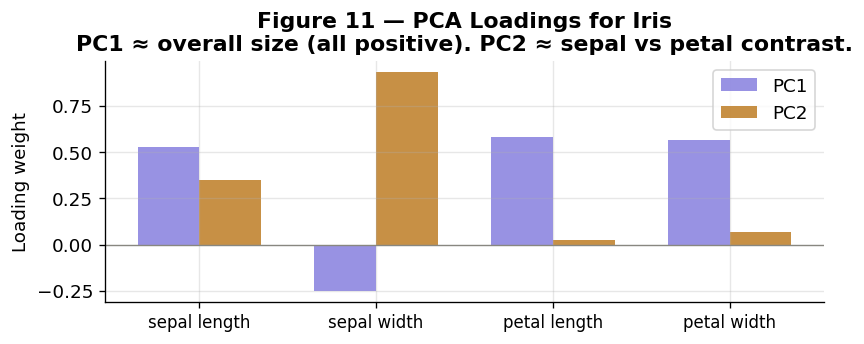

     sepal length  sepal width  petal length  petal width
PC1         0.527       -0.253         0.582        0.566
PC2         0.348        0.935         0.027        0.066


In [18]:
# ── PCA loadings for Iris: what does each PC capture? ─────────────────────────
load4 = pd.DataFrame(
    pca4_2d.components_,
    index=['PC1', 'PC2'],
    columns=[f.replace(' (cm)', '') for f in iris.feature_names]
)

fig, ax = plt.subplots(figsize=(7, 3))
x_pos = np.arange(len(iris.feature_names))
width = 0.35
ax.bar(x_pos - width/2, load4.loc['PC1'], width, color=PURP,  label='PC1', alpha=0.8)
ax.bar(x_pos + width/2, load4.loc['PC2'], width, color=AMBER, label='PC2', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f.replace(' (cm)', '') for f in iris.feature_names], fontsize=10)
ax.axhline(0, color=GRAY, linewidth=0.8)
ax.set_title('Figure 11 — PCA Loadings for Iris\n'
             'PC1 ≈ overall size (all positive). PC2 ≈ sepal vs petal contrast.',
             fontweight='bold')
ax.set_ylabel('Loading weight')
ax.legend()
plt.tight_layout()
plt.show()

print(load4.round(3))

---
## Summary — PCA Impact Across All Four Problems

| Problem | Model | Features → Components | Variance retained | Accuracy / R² change |
|---|---|---|---|---|
| California Housing | Linear Regression | varies → k₁ | 95% | Marginal; Ridge handles collinearity too |
| Pima Diabetes | Logistic Regression | 8 → k₂ | 95% | Slight; cleaner decision boundary |
| Loan Approval | Decision Tree | 9 → k₃ | 95% | Minimal; trees are PCA-robust |
| Iris | KNN | 4 → 2 | ~96% | Maintained accuracy + 2D visualisation |

### When PCA helps most
- **Distance-based models (KNN)** — removing redundant dimensions directly improves the distance metric.
- **Linear models with multicollinearity** — $(X^T X)^{-1}$ is better conditioned on orthogonal inputs.
- **Visualisation** — any dataset can be projected to 2D for inspection, regardless of original dimensionality.

### When PCA is less useful
- **Decision trees** — they already select the most discriminative feature at each node; PCA components (being linear combinations) can actually obscure interpretability.
- **When interpretability matters** — PCA coefficients are combinations of all original features; you cannot say "income raised the prediction by $X".
- **When features are already independent** — no collinearity means nothing for PCA to resolve.

### The key rule
> **Always compare with and without PCA.** PCA is a tool, not a universal improvement. Use the scree plot to choose k, verify with cross-validation, and report both results.

---
*This notebook accompanies the four main project notebooks.*